In [1]:
import glob
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import awswrangler as wr
from dotenv import load_dotenv
load_dotenv('../../../../../.env')

s3_client = boto3.client('s3')
S3_BUCKET_NAME = 'techcatalyst-raw'

In [ ]:
image_paths = glob.glob('Images/*')

for image in image_paths: 
    if '.jpg' in image:
        image_name = 'MELISSA/AI/IMAGES_RAW/'+image.split('/')[-1]
        s3_client.upload_file(Filename=image,
                                Bucket= S3_BUCKET_NAME,
                                Key=image_name)

print('Successfully Uploaded to s3 Bucket')

Successfully Uploaded to s3 Bucket


In [32]:
# List of car makes to search for (already uppercase)
car_makes = [
    'TOYOTA', 'HONDA', 'FORD', 'CHEVROLET', 'NISSAN', 'JEEP', 'HYUNDAI', 'KIA',
    'SUBARU', 'RAM', 'GMC', 'BMW', 'MERCEDES-BENZ', 'LEXUS', 'AUDI', 'VOLKSWAGEN',
    'TESLA', 'ACURA', 'CADILLAC', 'CHRYSLER', 'DODGE', 'INFINITI', 'LINCOLN', 'MAZDA'
]

# List of full US state names for searching
us_state_names = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
    'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
    'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
    'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'District of Columbia'
]

In [3]:
# listing all images we uploaded
rekognition_client = boto3.client('rekognition')
rekognition_output = []

objects = s3_client.list_objects(Bucket='techcatalyst-raw',
                                    Prefix='MELISSA/AI/IMAGES_RAW/')

for obj in objects.get('Contents',[]):
    s3_key = obj['Key']
    response = rekognition_client.detect_text(
        Image={'S3Object': {'Bucket': S3_BUCKET_NAME, 'Name': s3_key}}
    )
    print(response)

    detected_text = [item['DetectedText'] for item in response['TextDetections'] if item['Type'] == 'WORD']
    
    # rekognition_output.append({
    #     'image_name': 's3://techcatalyst-raw/'+s3_key, 
    #     'labels': detected_text
    # })


print(rekognition_output)



{'TextDetections': [{'DetectedText': 'VA 4164979', 'Type': 'LINE', 'Id': 0, 'Confidence': 99.38411712646484, 'Geometry': {'BoundingBox': {'Width': 0.10272216796875, 'Height': 0.0400390625, 'Left': 0.0999755859375, 'Top': 0.1748046875}, 'Polygon': [{'X': 0.0999755859375, 'Y': 0.1748046875}, {'X': 0.20269775390625, 'Y': 0.1748046875}, {'X': 0.20269775390625, 'Y': 0.21484375}, {'X': 0.0999755859375, 'Y': 0.21484375}]}}, {'DetectedText': 'NOV', 'Type': 'LINE', 'Id': 1, 'Confidence': 100.0, 'Geometry': {'BoundingBox': {'Width': 0.10009339451789856, 'Height': 0.0958026796579361, 'Left': 0.10553361475467682, 'Top': 0.22323094308376312}, 'Polygon': [{'X': 0.10553361475467682, 'Y': 0.22713987529277802}, {'X': 0.20447833836078644, 'Y': 0.22323094308376312}, {'X': 0.20562700927257538, 'Y': 0.3151246905326843}, {'X': 0.10668228566646576, 'Y': 0.3190336227416992}]}}, {'DetectedText': 'VIRGINIA', 'Type': 'LINE', 'Id': 2, 'Confidence': 98.82801055908203, 'Geometry': {'BoundingBox': {'Width': 0.439384

KeyboardInterrupt: 

In [67]:
processed_data = []

for item in rekognition_output:
    image_name = item['image_name']

    # concatinating the words found in the image
    full_text = " ".join(item['labels']).upper()
    
    # placeholders
    found_make = None
    found_state = None
    
    # --- Find Car Make ---
    for make in car_makes:
        if make in full_text:
            found_make = make.title()
            break 
            
    # --- Find State Name ---
    for state_name in us_state_names:
        if state_name.upper() in full_text:
            found_state = state_name
            break

    # Add the extracted info to our list
    processed_data.append({
        'image_name': image_name,
        'make': found_make,
        'state': found_state
    })

# Create the DataFrame from our list of processed dictionaries
df = pd.DataFrame(processed_data)

# For better presentation, replace Python's 'None' with a 'Not Found' string
df.fillna('Not Found', inplace=True)

print("Final DataFrame:")
display(df)

Final DataFrame:


,image_name,make,state
0,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/19...,Not Found,Virginia
1,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/1a...,Not Found,California
2,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/1c...,Not Found,Virginia
3,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/1c...,Ford,California
4,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/1d...,Not Found,Virginia
5,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/27...,Toyota,Pennsylvania
6,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/29...,Honda,Texas
7,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/2c...,Not Found,California
8,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/2c...,Not Found,California
9,s3://techcatalyst-raw/MELISSA/AI/IMAGES_RAW/2f...,Not Found,Virginia


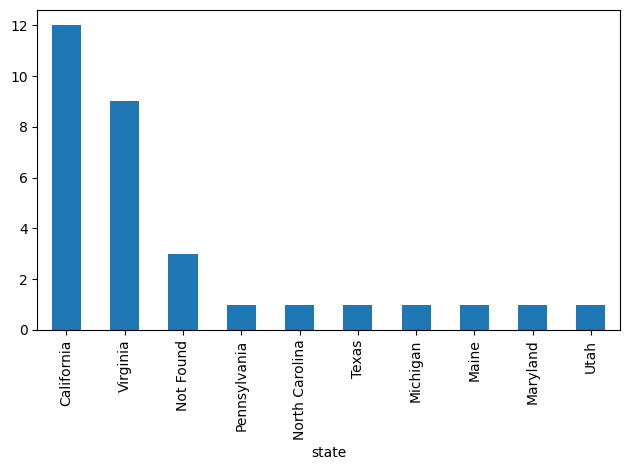

In [62]:
df['state'].value_counts().plot.bar()
plt.tight_layout()
plt.savefig('barchart_states.jpg')

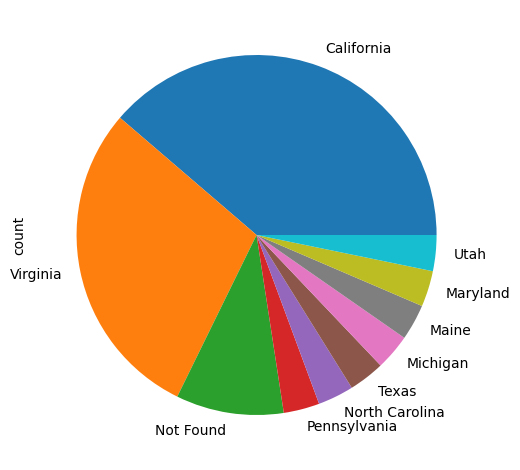

In [63]:
df['state'].value_counts().plot.pie()
plt.tight_layout()
plt.savefig('piechart_states.jpg')

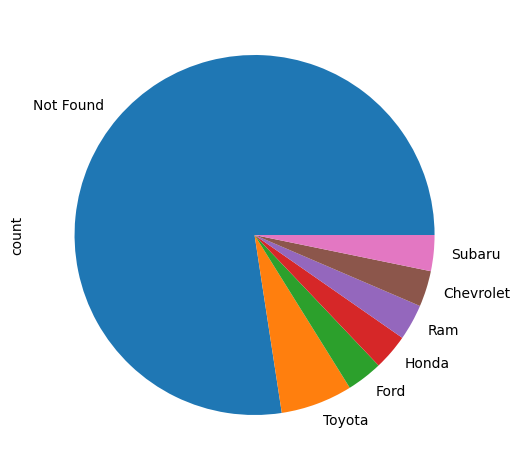

In [64]:
df['make'].value_counts().plot.pie()
plt.tight_layout()
plt.savefig('piechart_makes.jpg')

In [ ]:
charts_to_upload = ['barchart_states.jpg','piechart_makes.jpg','piechart_states.jpg']

for chart in charts_to_upload:
    s3_client.upload_file(
        Bucket=S3_BUCKET_NAME,
        Filename=chart,
        Key='MELISSA/AI/IMAGES_PROCESSED/'+chart
    )

wr.s3.to_parquet(
    df=df,
    path='s3://techcatalyst-raw/MELISSA/AI/IMAGES_PROCESSED/results.parquet'    
)